In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob

import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Download Traffic Sign Dataset

!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip

# Extract Dataset

!unzip -qq GTSRB_Final_Training_Images.zip

--2026-05-21 01:46:05--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  15.0MB/s    in 23s     

2026-05-21 01:46:29 (11.5 MB/s) - ‘GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]



In [ ]:
# Explore Dataset Folders

train_folders = sorted(glob('GTSRB/Final_Training/Images/*'))

print("Total Classes:", len(train_folders))

Total Classes: 43


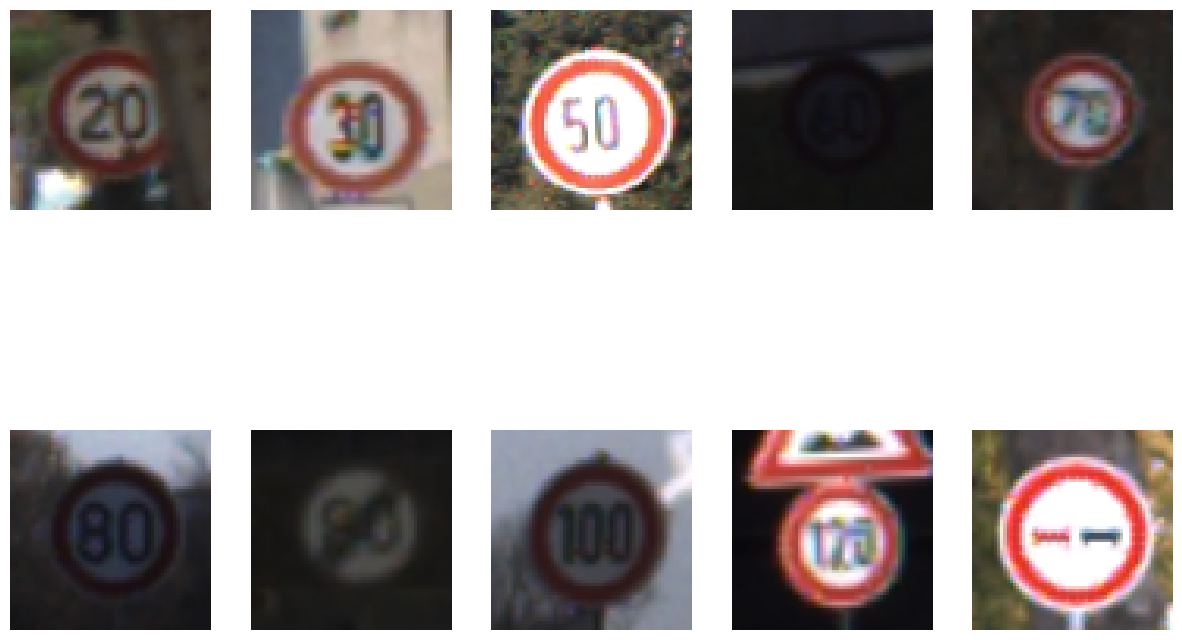

In [ ]:
images = []

# Take one random image from first 10 folders
for folder in train_folders[:10]:

    files = os.listdir(folder)

    img_path = folder + "/" + files[0]

    image = cv2.imread(img_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (64, 64))

    images.append(image)


# Show images one by one
plt.figure(figsize=(15,10))

for i in range(len(images)):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [ ]:
import shutil
from pathlib import Path

# Create Dataset Folder Structure

DATA_DIR = Path("data")

DATASETS = ["train", "val", "test"]

class_names = [
    "speed_limit_30",
    "speed_limit_50",
    "priority_road",
    "give_way",
    "stop",
    "no_entry",
    "turn_right",
    "road_work"
]

class_indices = [1, 2, 12, 13, 14, 17, 33, 25]

# Create Folders

for dataset in DATASETS:

    for class_name in class_names:

        (DATA_DIR / dataset / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

print("Folders Created Successfully")

Folders Created Successfully


In [ ]:
# Split Images Into Train, Validation and Test

for i, class_index in enumerate(class_indices):

    image_paths = np.array(
        glob(f"{train_folders[class_index]}/*.ppm")
    )

    class_name = class_names[i]

    print(f"{class_name}: {len(image_paths)} images")

    np.random.shuffle(image_paths)

    split_data = np.split(
        image_paths,
        [
            int(0.8 * len(image_paths)),
            int(0.9 * len(image_paths))
        ]
    )

    dataset_split = zip(DATASETS, split_data)

    for dataset_name, images in dataset_split:

        for image_path in images:

            shutil.copy(
                image_path,
                f"{DATA_DIR}/{dataset_name}/{class_name}/"
            )

print("Dataset Split Completed")

speed_limit_30: 2220 images
speed_limit_50: 2250 images
priority_road: 2100 images
give_way: 2160 images
stop: 780 images
no_entry: 1110 images
turn_right: 689 images
road_work: 1500 images
Dataset Split Completed


In [ ]:
# Image Normalization Values (ImageNet)

mean_values = [0.485, 0.456, 0.406]
std_values = [0.229, 0.224, 0.225]


# Data Transforms

data_transforms = {

    "train": transforms.Compose([

        transforms.RandomResizedCrop(224),

        transforms.RandomRotation(15),

        transforms.RandomHorizontalFlip(),

        transforms.ToTensor(),

        transforms.Normalize(mean_values, std_values)

    ]),

    "val": transforms.Compose([

        transforms.Resize(256),

        transforms.CenterCrop(224),

        transforms.ToTensor(),

        transforms.Normalize(mean_values, std_values)

    ]),

    "test": transforms.Compose([

        transforms.Resize(256),

        transforms.CenterCrop(224),

        transforms.ToTensor(),

        transforms.Normalize(mean_values, std_values)

    ])

}

print("Transforms Created Successfully")

Transforms Created Successfully


In [ ]:
# Offline Augmentation for Minority Classes

from torchvision.utils import save_image

augmentation_transform = transforms.Compose([

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)
    ),

    transforms.ToTensor()

])

# Target Images Per Class

TARGET_SIZE = 2200

# Minority Classes

minority_classes = [
    "stop",
    "turn_right",
    "no_entry"
]

for class_name in minority_classes:

    class_path = f"{DATA_DIR}/train/{class_name}"

    image_paths = glob(f"{class_path}/*")

    current_count = len(image_paths)

    print(f"\nClass: {class_name}")

    print(f"Current Images: {current_count}")

    images_needed = TARGET_SIZE - current_count

    print(f"Augmented Images Needed: {images_needed}")

    count = 0

    while count < images_needed:

        image_path = np.random.choice(image_paths)

        image = Image.open(image_path).convert("RGB")

        augmented_image = augmentation_transform(image)

        save_path = (
            f"{class_path}/aug_{count}.png"
        )

        save_image(augmented_image, save_path)

        count += 1

    print(f"Balanced {class_name}")


Class: stop
Current Images: 624
Augmented Images Needed: 1576
Balanced stop

Class: turn_right
Current Images: 551
Augmented Images Needed: 1649
Balanced turn_right

Class: no_entry
Current Images: 888
Augmented Images Needed: 1312
Balanced no_entry


In [ ]:
# Final Dataset Count After Augmentation

print("Final Dataset Distribution\n")

total_images = 0

for class_name in class_names:

    class_path = f"{DATA_DIR}/train/{class_name}"

    image_count = len(
        glob(f"{class_path}/*")
    )

    total_images += image_count

    print(f"{class_name}: {image_count} images")

print(f"\nTotal Training Images: {total_images}")

Final Dataset Distribution

speed_limit_30: 1776 images
speed_limit_50: 1800 images
priority_road: 1680 images
give_way: 1728 images
stop: 2200 images
no_entry: 2200 images
turn_right: 2200 images
road_work: 1200 images

Total Training Images: 14784


In [ ]:
# Create PyTorch Datasets

image_datasets = {

    dataset: datasets.ImageFolder(
        root=f"{DATA_DIR}/{dataset}",
        transform=data_transforms[dataset]
    )

    for dataset in DATASETS
}


# Create DataLoaders

data_loaders = {

    dataset: DataLoader(
        image_datasets[dataset],
        batch_size=32,
        shuffle=True,
        num_workers=2
    )

    for dataset in DATASETS
}


# Dataset Sizes

dataset_sizes = {

    dataset: len(image_datasets[dataset])

    for dataset in DATASETS
}


# Class Names

class_names = image_datasets["train"].classes

print("Classes:", class_names)

print("Dataset Sizes:", dataset_sizes)

Classes: ['give_way', 'no_entry', 'priority_road', 'road_work', 'speed_limit_30', 'speed_limit_50', 'stop', 'turn_right']
Dataset Sizes: {'train': 14784, 'val': 1281, 'test': 1281}


In [ ]:
# Count Images in Each Selected Class

for i, class_index in enumerate(class_indices):

    image_paths = glob(
        f"{train_folders[class_index]}/*.ppm"
    )

    print(
        f"{class_names[i]} : {len(image_paths)} images"
    )

give_way : 2220 images
no_entry : 2250 images
priority_road : 2100 images
road_work : 2160 images
speed_limit_30 : 780 images
speed_limit_50 : 1110 images
stop : 689 images
turn_right : 1500 images


In [ ]:
# Device Configuration

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [ ]:
# Create ResNet34 Model

def create_model(num_classes):

    model = models.resnet34(weights="DEFAULT")

    # Get Input Features of Final Layer

    num_features = model.fc.in_features

    # Replace Final Layer

    model.fc = nn.Linear(num_features, num_classes)

    return model


# Create Model

model = create_model(len(class_names))

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 180MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Training Function

def train_epoch(model, data_loader, loss_function,
                optimizer, device):

    model.train()

    running_loss = 0.0

    correct_predictions = 0

    for inputs, labels in data_loader:

        inputs = inputs.to(device)

        labels = labels.to(device)

        # Forward Pass

        outputs = model(inputs)

        _, predictions = torch.max(outputs, 1)

        loss = loss_function(outputs, labels)

        # Backpropagation

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Statistics

        running_loss += loss.item()

        correct_predictions += torch.sum(
            predictions == labels
        )

    epoch_loss = running_loss / len(data_loader)

    epoch_accuracy = correct_predictions.double() / dataset_sizes["train"]

    return epoch_loss, epoch_accuracy.item()

In [ ]:
# Validation / Evaluation Function

def evaluate_model(model, data_loader,
                   loss_function, device):

    model.eval()

    running_loss = 0.0

    correct_predictions = 0

    with torch.no_grad():

        for inputs, labels in data_loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            # Forward Pass

            outputs = model(inputs)

            _, predictions = torch.max(outputs, 1)

            loss = loss_function(outputs, labels)

            # Statistics

            running_loss += loss.item()

            correct_predictions += torch.sum(
                predictions == labels
            )

    epoch_loss = running_loss / len(data_loader)

    epoch_accuracy = (
        correct_predictions.double()
        / dataset_sizes["val"]
    )

    return epoch_loss, epoch_accuracy.item()

In [ ]:
# Main Training Function

def train_model(model, data_loaders,
                dataset_sizes, device,
                epochs=10):

    # Loss Function

    loss_function = nn.CrossEntropyLoss()

    # Optimizer

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.001,
        momentum=0.9
    )

    # Learning Rate Scheduler

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=5,
        gamma=0.1
    )

    # Store History

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_accuracy = 0.0

    # Training Loop

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        print("-" * 30)

        # Training

        train_loss, train_acc = train_epoch(
            model,
            data_loaders["train"],
            loss_function,
            optimizer,
            device
        )

        # Validation

        val_loss, val_acc = evaluate_model(
            model,
            data_loaders["val"],
            loss_function,
            device
        )

        # Scheduler Step

        scheduler.step()

        # Save History

        history["train_loss"].append(train_loss)

        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)

        history["val_acc"].append(val_acc)

        # Save Best Model

        if val_acc > best_accuracy:

            torch.save(
                model.state_dict(),
                "best_model.pth"
            )

            best_accuracy = val_acc

        # Print Metrics

        print(f"Train Loss : {train_loss:.4f}")

        print(f"Train Acc  : {train_acc:.4f}")

        print(f"Val Loss   : {val_loss:.4f}")

        print(f"Val Acc    : {val_acc:.4f}")

    print("\nTraining Complete")

    print(f"Best Validation Accuracy: {best_accuracy:.4f}")

    return model, history

In [ ]:
# Device Configuration

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [ ]:
# Train Model

model, history = train_model(
    model,
    data_loaders,
    dataset_sizes,
    device,
    epochs=15
)


Epoch 1/15
------------------------------
Train Loss : 0.3633
Train Acc  : 0.8724
Val Loss   : 0.0351
Val Acc    : 0.9922

Epoch 2/15
------------------------------
Train Loss : 0.1170
Train Acc  : 0.9585
Val Loss   : 0.0291
Val Acc    : 0.9906

Epoch 3/15
------------------------------
Train Loss : 0.0912
Train Acc  : 0.9667
Val Loss   : 0.0128
Val Acc    : 0.9977

Epoch 4/15
------------------------------
Train Loss : 0.0810
Train Acc  : 0.9690
Val Loss   : 0.0068
Val Acc    : 0.9984

Epoch 5/15
------------------------------
Train Loss : 0.0738
Train Acc  : 0.9739
Val Loss   : 0.0039
Val Acc    : 1.0000

Epoch 6/15
------------------------------
Train Loss : 0.0636
Train Acc  : 0.9765
Val Loss   : 0.0036
Val Acc    : 1.0000

Epoch 7/15
------------------------------
Train Loss : 0.0639
Train Acc  : 0.9765
Val Loss   : 0.0033
Val Acc    : 1.0000

Epoch 8/15
------------------------------
Train Loss : 0.0536
Train Acc  : 0.9800
Val Loss   : 0.0030
Val Acc    : 1.0000

Epoch 9/15
----

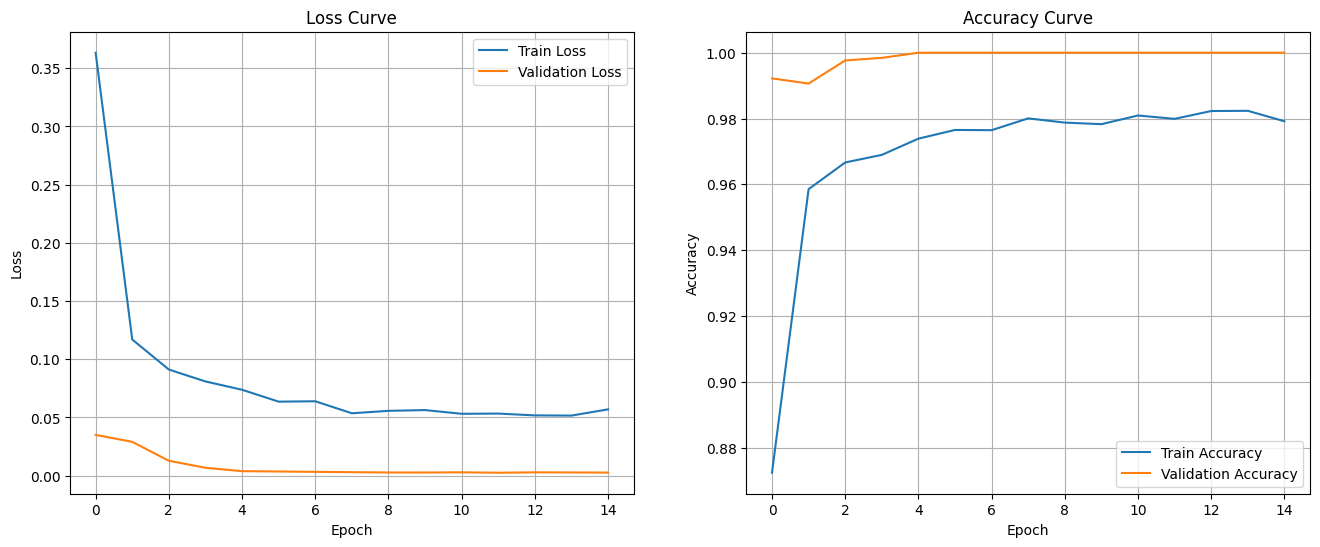

In [ ]:
# Plot Training History

def plot_training_history(history):

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(16, 6)
    )

    # Loss Graph

    ax1.plot(
        history["train_loss"],
        label="Train Loss"
    )

    ax1.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    ax1.set_title("Loss Curve")

    ax1.set_xlabel("Epoch")

    ax1.set_ylabel("Loss")

    ax1.legend()

    ax1.grid(True)

    # Accuracy Graph

    ax2.plot(
        history["train_acc"],
        label="Train Accuracy"
    )

    ax2.plot(
        history["val_acc"],
        label="Validation Accuracy"
    )

    ax2.set_title("Accuracy Curve")

    ax2.set_xlabel("Epoch")

    ax2.set_ylabel("Accuracy")

    ax2.legend()

    ax2.grid(True)

    plt.show()


# Display Graphs

plot_training_history(history)

In [ ]:
# Get Predictions From Test Dataset

def get_predictions(model, data_loader):

    model.eval()

    predictions = []

    actual_labels = []

    with torch.no_grad():

        for inputs, labels in data_loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            predictions.extend(preds.cpu().numpy())

            actual_labels.extend(labels.numpy())

    return predictions, actual_labels


# Generate Predictions

y_pred, y_true = get_predictions(
    model,
    data_loaders["test"]
)

print("Predictions Generated Successfully")

Predictions Generated Successfully


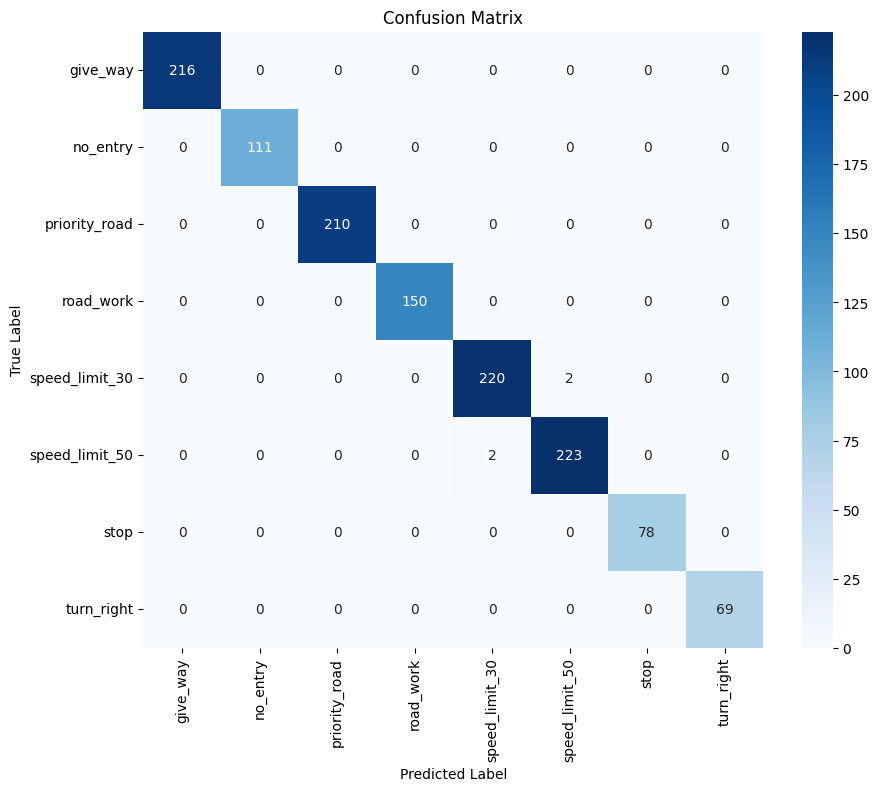

In [ ]:
# Generate Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

      give_way       1.00      1.00      1.00       216
      no_entry       1.00      1.00      1.00       111
 priority_road       1.00      1.00      1.00       210
     road_work       1.00      1.00      1.00       150
speed_limit_30       0.99      0.99      0.99       222
speed_limit_50       0.99      0.99      0.99       225
          stop       1.00      1.00      1.00        78
    turn_right       1.00      1.00      1.00        69

      accuracy                           1.00      1281
     macro avg       1.00      1.00      1.00      1281
  weighted avg       1.00      1.00      1.00      1281



In [ ]:
# Evaluation Metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Accuracy

accuracy = accuracy_score(y_true, y_pred)

# Precision

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

# Recall

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

# F1 Score

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# Print Metrics

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9969
Precision : 0.9969
Recall    : 0.9969
F1-Score  : 0.9969
